### Find latent features in Place cells using Matrioshka SAEs

Main goal: look at different levels of features in a 3-level MSAE

Steps:

1. Train MSAE on spikes dataset

2. Create (topk) sae feature df

3. Create stim (meta)data df

4. Interp / autointerp
    
    a. Create infra for finding stim at times of particular feature(s)
    
    b. Create infra for finding topk SAE features that fire at times of particular stim

In [1]:
"""Import packages."""

import math
from collections import defaultdict
from dataclasses import dataclass
from functools import partial
from pathlib import Path
from typing import Callable, List, Optional, Tuple
import os 

# import jax
import numpy as np
import pandas as pd
import seaborn as sns
import torch as t
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache
from einops import asnumpy, einsum, rearrange, reduce, repeat, pack, parse_shape, unpack
from einops.layers.torch import Rearrange, Reduce
from IPython.display import HTML
from jaxtyping import Float, Int
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from mpl_toolkits.mplot3d import Axes3D
from plotly import express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots
from rich import print as rprint
from sklearn.metrics import classification_report, confusion_matrix, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from torch import bfloat16, nn, Tensor
from torch.nn import functional as F
from torcheval.metrics.functional import r2_score as tm_r2_score
from tqdm.notebook import tqdm


from torch.utils.data import Dataset, DataLoader
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

from mini import train as mt
from mini.util import vec_r2

In [2]:
"""Set notebook settings."""

%load_ext autoreload
%autoreload 2
# %flow mode reactive

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 25)

In [3]:
# Choose dataset to use:

# options: "20Hz_4PCs_5Hz_96noise", "40Hz_4PCs_5Hz_96noise", "20Hz_4PCs_5Hz_32noise"
folder = "20Hz_50PCs_5Hz_50noise"

In [4]:
# Load simulated place cells spike matrix (this matrix has data from 4 simulated place cells and 96 random cells - aka noise)

spike_matrix = np.load("./" + folder + "/spike_matrix.npy")

print(spike_matrix.shape) 

# We want it the other way around, neurons = columns and rows = timepoints
spike_matrix = spike_matrix.T

print(spike_matrix.shape)

(100, 60000)
(60000, 100)


### Train MSAE

In [5]:
dsae_topk_map = {128: 2} #, 64: 4, 128: 8}
dsae_topk_map = dict(sorted(dsae_topk_map.items()))  # ensure sorted from smallest to largest
dsae_loss_x_map = {128: 1} #, 64: 1.25, 128: 1.5}
dsae_loss_x_map = dict(sorted(dsae_loss_x_map.items()))
dsae = max(dsae_topk_map.keys())
n_inst = 2
# gonna want a gpu if training! not necessary if loading saved features from a trained model
device = t.device("cuda" if t.cuda.is_available() else "cpu")
print(f"{device=}")

device=device(type='cuda')


In [6]:
# convert to torch tensor and normalize spike counts

spike_cts = t.from_numpy(spike_matrix).bfloat16().to(device)
#spike_cts /= spike_cts.max()

mean = spike_cts.mean(dim=0, keepdim=True)
std = spike_cts.std(dim=0, keepdim=True)
spike_cts = (spike_cts - mean) / (std) + 1e-8

In [7]:
sae_cfg = mt.SaeConfig(
    n_input_ae=spike_cts.shape[1],
    dsae_topk_map=dsae_topk_map,
    dsae_loss_x_map=dsae_loss_x_map,
    seq_len=1,
    n_instances=n_inst,
)
sae = mt.Sae(sae_cfg).to(device)
loss_fn = mt.msle
tau = 1.0
lr = lr = 5e-3

n_epochs = 20
batch_sz = 1024
n_steps = spike_cts.shape[0] // batch_sz * n_epochs
log_freq = n_steps // n_epochs // 2
dead_neuron_window = n_steps // n_epochs // 3

data_log = mt.optimize(  # train model
    spk_cts=spike_cts,
    sae=sae,
    loss_fn=loss_fn,
    optimizer=t.optim.Adam(sae.parameters(), lr=lr),
    use_lr_sched=True,
    dead_neuron_window=dead_neuron_window,
    n_steps=n_steps,
    log_freq=log_freq,
    batch_sz=batch_sz,
    log_wandb=False,
    plot_l0=False,
    tau=tau
)

SAE batch training step: 100%|██████████| 1160/1160 [00:03<00:00, 290.50it/s, loss=0.06093,  l0_mean=2.0, l0_std=2.5322539806365967, frac_dead=0.0]       


## Validate SAEs

In [8]:
"""Check for nans in weights."""

sae.W_dec.isnan().sum(), sae.W_enc.isnan().sum()

(tensor(0, device='cuda:0'), tensor(0, device='cuda:0'))

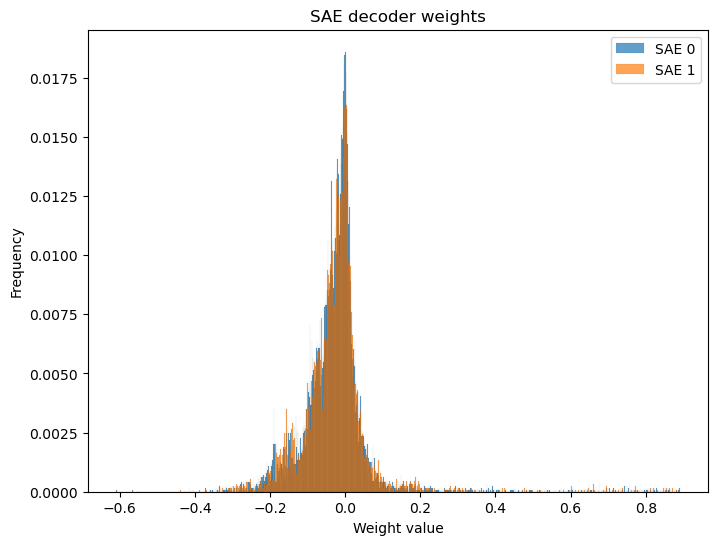

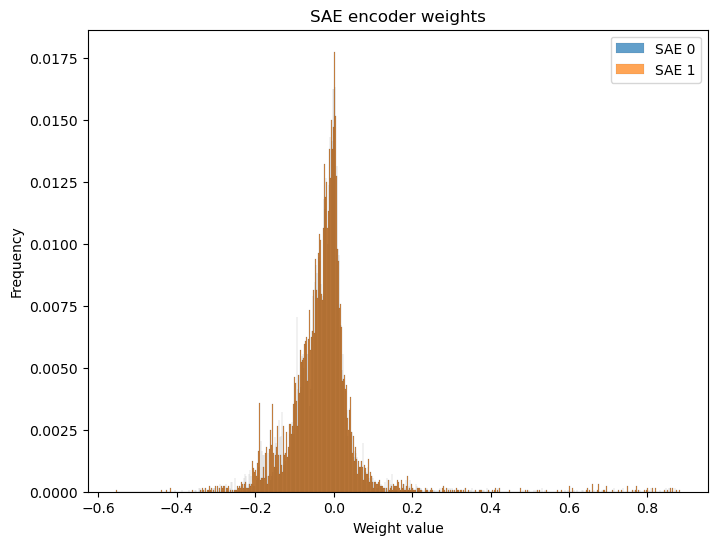

In [9]:
"""Visualize weights."""

fig, ax = plt.subplots(figsize=(8, 6))
for inst in range(n_inst):
    W_dec_flat = asnumpy(sae.W_dec[inst].float()).ravel()
    sns.histplot(W_dec_flat, bins=1000, stat="probability", alpha=0.7, label=f"SAE {inst}")
    
ax.set_title("SAE decoder weights")
ax.set_xlabel("Weight value")
ax.set_ylabel("Frequency")
ax.legend()

fig, ax = plt.subplots(figsize=(8, 6))
for inst in range(n_inst):
    W_enc_flat = asnumpy(sae.W_enc[inst].float()).ravel()
    sns.histplot(W_dec_flat, bins=1000, stat="probability", alpha=0.7, label=f"SAE {inst}")
    
ax.set_title("SAE encoder weights")
ax.set_xlabel("Weight value")
ax.set_ylabel("Frequency")
ax.legend()

SAE batch evaluation step: 100%|██████████| 58/58 [00:00<00:00, 96.31it/s]


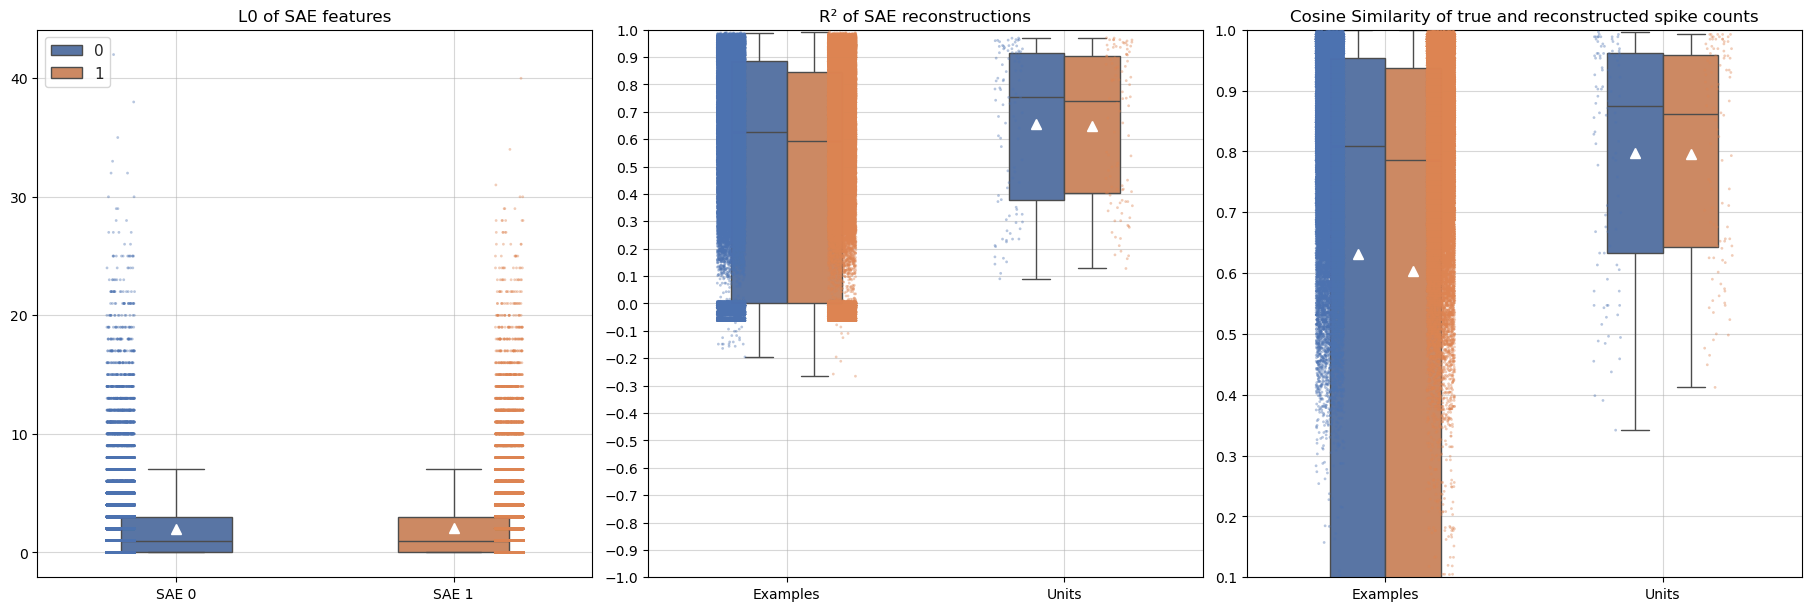

In [10]:
"""Visualize metrics over all examples and units."""

topk_acts_4d, recon_spk_cts, r2_per_unit, _, cossim_per_unit, _ = mt.eval_model(spike_cts, sae, batch_sz=batch_sz)

In [11]:
"""Calculate variance explained of summed spike counts."""

# Var explained for summed spike counts.
n_recon_examples = recon_spk_cts.shape[0]
recon_summed_spk_cts = reduce(recon_spk_cts, "example inst unit -> example inst", "sum")
actual_summed_spk_cts = reduce(spike_cts, "example unit -> example", "sum")
actual_summed_spk_cts = actual_summed_spk_cts[0:n_recon_examples]  # trim to match
for inst in range(n_inst):
    r2 = r2_score(
        asnumpy(actual_summed_spk_cts.float()), asnumpy(recon_summed_spk_cts[:, inst].float())
    )
    print(f"SAE instance {inst} R² (summed spike count over all units per example) = {r2:.3f}")

SAE instance 0 R² (summed spike count over all units per example) = -0.017
SAE instance 1 R² (summed spike count over all units per example) = 0.033


## Remove bad units and retrain

In [ ]:
#Re-train.

r2_thresh = 0.1
inst = 0
r2_per_unit = r2_per_unit[:, inst]
keep_mask = r2_per_unit > r2_thresh
print(f"frac units above {r2_thresh=}: {keep_mask.sum() / keep_mask.shape[0]:.2f}")
print(f"Number to keep: {keep_mask.sum()} / {keep_mask.shape[0]}")

# Remove units and retrain
spk_cts = spike_cts[:, keep_mask]

sae_cfg = mt.SaeConfig(
    n_input_ae=spk_cts.shape[1],
    dsae_topk_map=dsae_topk_map,
    dsae_loss_x_map=dsae_loss_x_map,
    seq_len=1,
    n_instances=n_inst,
)
sae = mt.Sae(sae_cfg).to(device)
loss_fn = mt.msle
tau = 1.0
lr = 5e-4

n_epochs = 20
batch_sz = 16
n_steps = spk_cts.shape[0] // batch_sz * n_epochs
log_freq = n_steps // n_epochs // 2
dead_neuron_window = n_steps // n_epochs // 3

data_log = mt.optimize(  # train model
    spk_cts=spk_cts,
    sae=sae,
    loss_fn=loss_fn,
    optimizer=t.optim.Adam(sae.parameters(), lr=lr),
    use_lr_sched=True,
    dead_neuron_window=dead_neuron_window,
    n_steps=n_steps,
    log_freq=log_freq,
    batch_sz=batch_sz,
    log_wandb=False,
    plot_l0=False,
    tau=tau
)

In [ ]:

file_path = "./sae_latents_Z.npy"

if os.path.exists(file_path):
    os.remove(file_path)
    print("File deleted")
else:
    print("File not found")

In [ ]:
#Re-visualize metrics over all examples and units.


topk_acts_4d, recon_spk_cts, r2_per_unit, _, cossim_per_unit, _ = mt.eval_model(spk_cts, sae, batch_sz=batch_sz)

n_recon_examples = recon_spk_cts.shape[0]
recon_summed_spk_cts = reduce(recon_spk_cts, "example inst unit -> example inst", "sum")
actual_summed_spk_cts = reduce(spk_cts, "example unit -> example", "sum")
actual_summed_spk_cts = actual_summed_spk_cts[0:n_recon_examples]  # trim to match
for inst in range(n_inst):
    r2 = r2_score(
        asnumpy(actual_summed_spk_cts.float()), asnumpy(recon_summed_spk_cts[:, inst].float())
    )
    print(f"SAE instance {inst} R² (summed spike count over all units per example) = {r2:.3f}")


## Interpret features

In [ ]:

out_dir = Path("/workspace/SAE_place_cells/")
session_id = "31-08-2025_12_47_55"  # change to your session id

load_acts = False  # if True, will load saved feature activations
save_acts = False
sae_datafile = "sae_0.csv"  # set name of data file to load (or save to)

acts_df_save_path = out_dir / f"{session_id}" / "sae_features" / sae_datafile
acts_df_save_path.parent.mkdir(parents=True, exist_ok=True)

In [ ]:
"""Create dfs of feature activations."""

if not load_acts:

    # Convert tensor to numpy array for easier handling
    acts_array = asnumpy(topk_acts_4d)

    # Create DataFrame with the data
    acts_df = pd.DataFrame({
        "example_idx": acts_array[:, 0],
        "instance_idx": acts_array[:, 1],
        "feature_idx": acts_array[:, 2],
        "activation_value": acts_array[:, 3]
    })

    # Convert appropriate cols to ints
    acts_df["example_idx"] = acts_df["example_idx"].astype(int)
    acts_df["feature_idx"] = acts_df["feature_idx"].astype(int)
    acts_df["instance_idx"] = acts_df["instance_idx"].astype(int)

    n_recon_examples = int(acts_df.iloc[-1]["example_idx"]) + 1

print(acts_df.head(5))

In [ ]:
display(acts_df)

In [ ]:
"""Compare features from ("broad" or "general") and ("specific" or "nested") levels.

last_feat_idx_general = list(dsae_topk_map.keys())[0]
first_feat_idx_specific = list(dsae_topk_map.keys())[1]

print(features_df[features_df["feature_idx"] < last_feat_idx_general]["activation_frac"].describe())
print()
print(features_df[np.logical_and(
    features_df["feature_idx"] > last_feat_idx_general,
    features_df["feature_idx"] < first_feat_idx_specific
)]["activation_frac"].describe())
print()
print(features_df[features_df["feature_idx"] > first_feat_idx_specific]["activation_frac"].describe())"""

## Hunt for features

In [ ]:
"""For a particular feature, get times it fired + stim deta at these times."""

# Inputs you already have:
# pos: shape (T,) continuous linear position
# features_df["feature_idx"]:   shape (T, F) continuous activations (or binary 0/1)
# features_df["example_idx"]:   shape (T,) time vector (optional) or assume uniform sampling dt

from scipy.ndimage import gaussian_filter1d
import os

instance_to_visualize = 0
for instance in range(instance_to_visualize, instance_to_visualize + 1):
    print("--------------------------------------------------")
    print(f"Instance {instance}:")
    features_df = acts_df[acts_df["instance_idx"] == instance].reset_index(drop=True)
    print("  feature_idx range:",  features_df["feature_idx"].min(), "-",  features_df["feature_idx"].max())
    print("  n activations:", len( features_df))
    print("  n unique features:",  features_df["feature_idx"].nunique())
    print("  n unique examples:",  features_df["example_idx"].nunique())
    print()

    # Parameters (tune as needed)
    n_bins = 10
    sigma_bins = 1.0            # smoothing sigma in bin units. Set to 0 to skip smoothing.
    min_occupancy_s = 0.2       # seconds minimum occupancy per bin; set 0 to ignore
    save_dir = "feature_ratemaps"  # set None to show inline instead of saving
    row_normalize = True        # if True, scale each feature's ratemap to [0,1] for visualization
    plot_type = "line"          # "line" or "bar" (per feature)
    figsize = (6,3)

    # -----------------------------------------------------------------------

    # Basic checks
    assert 'feature_idx' in features_df.columns and 'example_idx' in features_df.columns, \
        "features_df must contain 'feature_idx' and 'example_idx' columns."

    # If activation values exist, use them; else create implied activation_value = 1 per row (count)
    if 'activation_value' in features_df.columns:
        features_df['activation_value'] = features_df['activation_value'].astype(float)
    else:
        features_df['activation_value'] = 1.0

    # Convert pos & t to numpy
    pos = np.load("./" + folder + "/positions.npy")
    time = np.load("./" + folder + "/timestamps.npy")
    T = len(pos)
    if 'time' in globals():
        t = np.asarray(time)
        # estimate dt as median diff; if irregular sampling you might compute occupancy per-sample differently
        dt = np.median(np.diff(t))
    else:
        dt = 1.0   # assume uniform sampling; occupancy in "samples" units

    # 1) define spatial bins and occupancy
    edges = np.linspace(pos.min(), pos.max(), n_bins + 1)
    bin_idx_all = np.digitize(pos, edges) - 1
    bin_idx_all = np.clip(bin_idx_all, 0, n_bins-1)

    # occupancy in seconds per bin
    counts = np.bincount(bin_idx_all, minlength=n_bins)
    T_bins = counts * dt
    p_bins = T_bins / T_bins.sum()

    # optionally mask low-occupancy bins
    low_occ_mask = T_bins < min_occupancy_s

    # 2) Map feature activations (rows) to bins using example_idx -> pos -> bin
    # Make sure example_idx is integer and indices are within range
    features_df = features_df.copy()
    features_df['example_idx'] = features_df['example_idx'].astype(int)
    features_df = features_df[(features_df['example_idx'] >= 0) & (features_df['example_idx'] < T)].reset_index(drop=True)
    # Map example -> position bin
    features_df['bin'] = bin_idx_all[features_df['example_idx'].values]

    # 3) Aggregate activations per feature x bin
    # We compute sum of activation_value per (feature, bin). For counts-based data this is just counts.
    agg = features_df.groupby(['feature_idx', 'bin'])['activation_value'].sum().unstack(fill_value=0)  # shape: (n_features, n_bins)
    # ensure all bins exist as columns
    agg = agg.reindex(columns=np.arange(n_bins), fill_value=0)

    # 4) Convert aggregated activations to occupancy-normalized ratemap
    # rate = total_activation_in_bin / occupancy_seconds_in_bin
    # If dt units are samples, this gives activations per second if activation_value counted spikes per sample
    occ = T_bins.copy().astype(float)
    occ[occ == 0] = np.nan  # avoid division by zero; we'll mask these later
    ratemap = agg.values / occ[np.newaxis, :]   # shape (n_features, n_bins)

    # 5) smoothing (optional)
    if sigma_bins > 0:
        # for a linear track use mode='constant' to avoid wrap-around
        ratemap_sm = gaussian_filter1d(ratemap, sigma=sigma_bins, axis=1, mode='constant')
    else:
        ratemap_sm = ratemap

    # 6) prepare plotting folder
    if save_dir is not None:
        os.makedirs(save_dir, exist_ok=True)

    # Function to compute a simple selectivity metric (peak / mean) for ordering
    peak_over_mean = (ratemap_sm.max(axis=1) + 1e-12) / (np.nanmean(ratemap_sm, axis=1) + 1e-12)
    # order features by peak bin (so place-like fields line up) or by peak_over_mean
    peak_bin = np.nanargmax(ratemap_sm, axis=1)
    order = np.argsort(peak_bin)  # primary sort by peak location
    # alternative: order = np.argsort(-peak_over_mean)  # by selectivity

    # 7) iterate and plot each feature's ratemap
    import math
    from matplotlib import gridspec

    feature_ids = agg.index.values
    for i_feat in order:
        feat = feature_ids[i_feat]  # actual feature_idx label (could be non-contiguous)
        row = ratemap_sm[i_feat, :].copy()
        # mask low-occupancy bins for plotting clarity
        row_vis = row.copy()
        row_vis[low_occ_mask] = np.nan

        if row_normalize:
            mx = np.nanmax(row_vis)
            if np.isfinite(mx) and mx > 0:
                row_vis = row_vis / mx

        # build plot
        fig, ax = plt.subplots(figsize=figsize)
        bins_centers = (edges[:-1] + edges[1:]) / 2.0

        if plot_type == "line":
            ax.plot(bins_centers, row_vis, marker='o', linestyle='-')
            ax.set_ylim(0, 1.05 if row_normalize else None)
        else:  # bar
            ax.bar(bins_centers, row_vis, width=(edges[1]-edges[0])*0.9, align='center')
            if row_normalize:
                ax.set_ylim(0,1.05)

        ax.set_xlabel("Position along track (bin centers)")
        ax.set_ylabel("Normalized activation" if row_normalize else "Activation / sec")
        ax.set_title(f"Feature {feat} — peak_bin={peak_bin[i_feat]}, peak_val={ratemap_sm[i_feat].max():.3g}")
        # optionally annotate occupancy under plot
        ax2 = ax.twinx()
        ax2.plot(bins_centers, T_bins, color='r', alpha=0.2)
        ax2.set_ylabel("Occupancy (s)", alpha=0.5)
        ax2.set_ylim(0, max(T_bins)*1.1)

        plt.tight_layout()
        plt.show()

        if save_dir:
            fname = os.path.join(save_dir, f"ratemap_feature_{feat}.png")
            fig.savefig(fname, dpi=150)
            plt.close(fig)

    # 8) Summary DF of metrics (optional)
    metrics_df = pd.DataFrame({
        "feature_idx": feature_ids,
        "peak_bin": peak_bin,
        "peak_value": ratemap_sm.max(axis=1),
        "mean_value": np.nanmean(ratemap_sm, axis=1),
        "selectivity": peak_over_mean
    })
    metrics_df = metrics_df.sort_values(['peak_bin', 'selectivity'], ascending=[True, False]).reset_index(drop=True)
    metrics_df.to_csv(os.path.join(save_dir, "feature_ratemap_metrics.csv"), index=False)
    print("Done. Ratemaps saved to:", save_dir)



## Validate results with PCA

Saved pos_float32.npy (float32 continuous grid), pos_idx64.npy (int64 indices), pos_bin_centers.npy (bin center values).
Explained variance ratio (PC1..): [0.0987 0.0471 0.0139 0.0117 0.0116 0.0115]


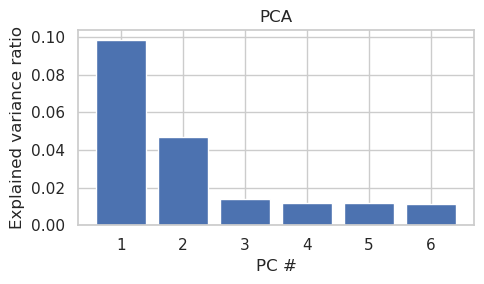

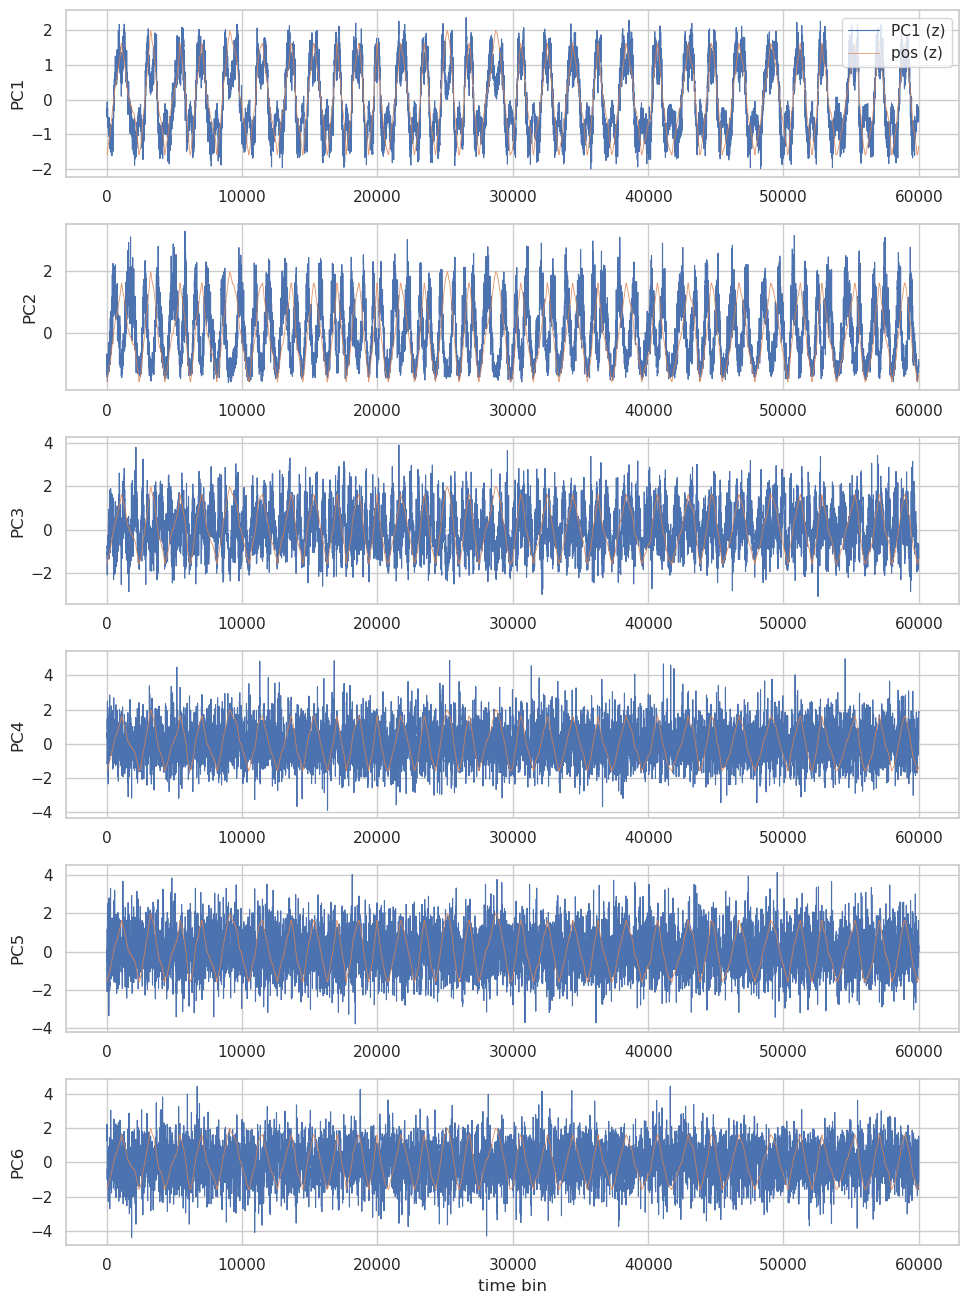

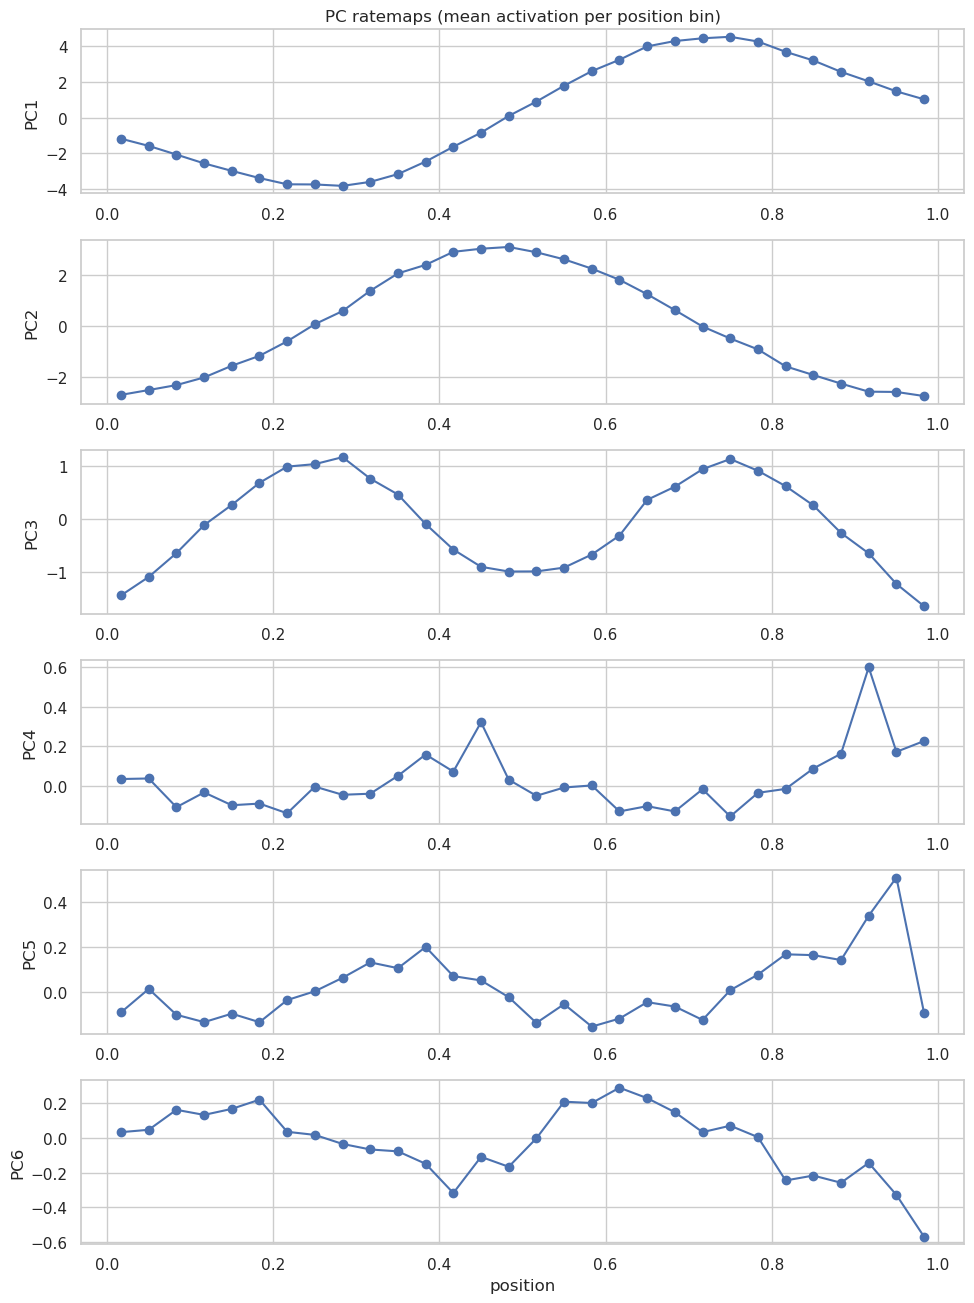

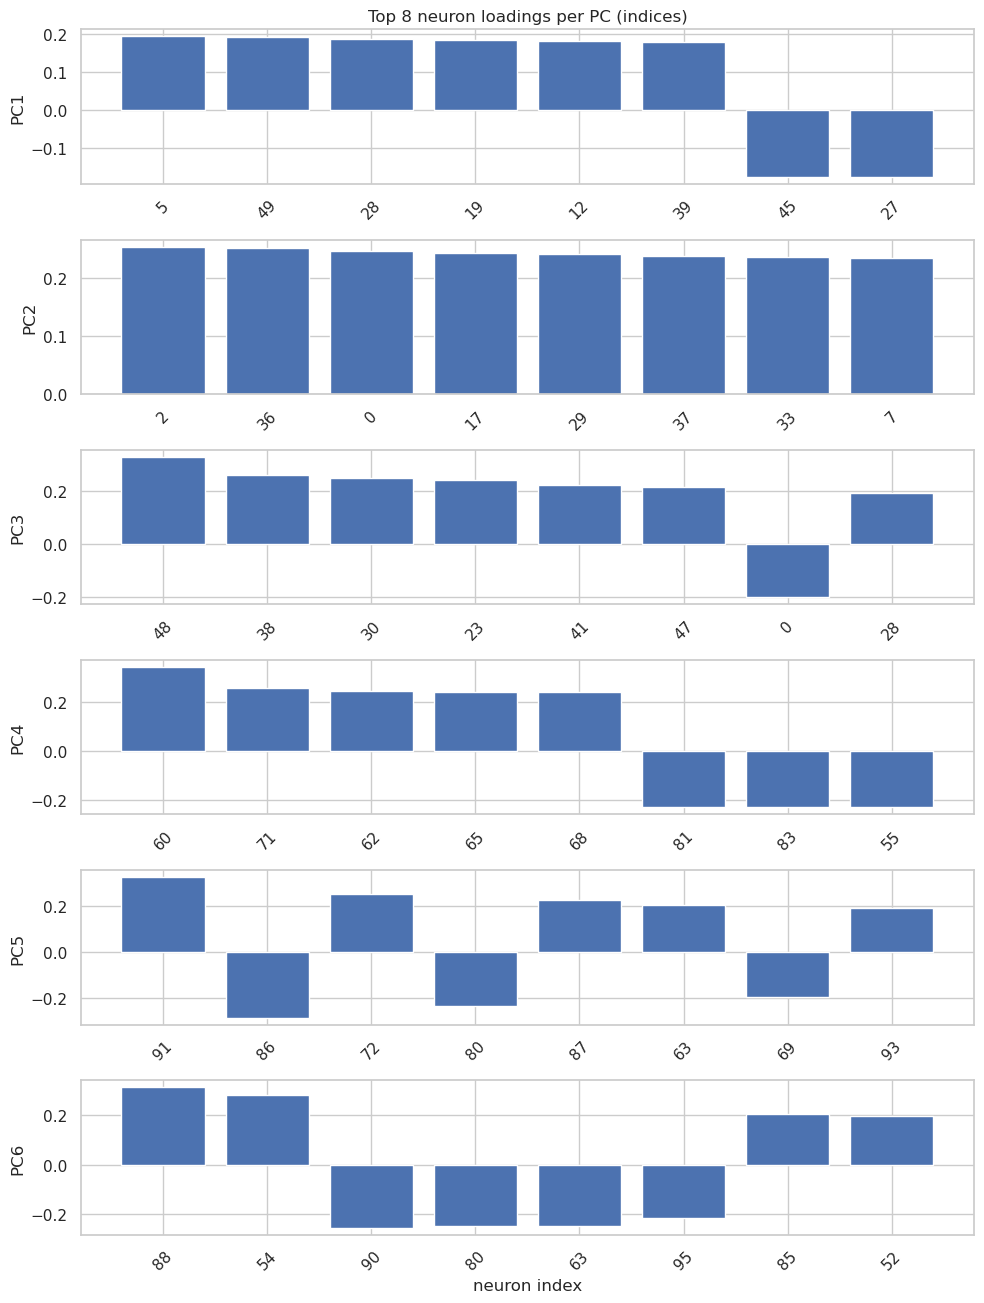

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# ---------- USER: ensure spike_cts (T, N) and pos (T,) are in scope ----------
# Example:
# spike_cts = np.load("spike_cts.npy")   # shape (T, N)
# pos = np.load("pos.npy")               # shape (T,)
# ---------------------------------------------------------------------------

def simple_pca_inspect(spike_cts, pos, n_components=6, n_pos_bins=30, smoothing_sigma=None):
    """
    Minimal PCA + plots for interpretation.
    Inputs:
      - spike_cts: (T, N) array of spike counts/rates
      - pos: (T,) continuous position along track
      - n_components: number of PCs to compute and plot
      - n_pos_bins: bins for ratemap plots
      - smoothing_sigma: optional gaussian smoothing (float); None => no smoothing
    """
    # --- basic checks & preprocessing ---
    spike_cts = spike_cts.detach().cpu().to(t.float32).numpy()
    #pos = pos.detach().cpu().numpy()
    X = np.asarray(spike_cts).astype(float)
    pos = np.asarray(pos).ravel()
    if X.shape[0] != pos.shape[0]:
        raise ValueError("Time dimension mismatch: spike_cts.shape[0] != pos.shape[0]")
    # optional smoothing (along time axis)
    if smoothing_sigma is not None and smoothing_sigma > 0:
        from scipy.ndimage import gaussian_filter1d
        X = gaussian_filter1d(X, sigma=smoothing_sigma, axis=0, mode='reflect')
    # quick variance-stabilizing transform (optional but often useful)
    X = np.sqrt(X + 3./8.)
    # per-neuron z-score
    X = (X - X.mean(axis=0)) / (X.std(axis=0) + 1e-8)

    # --- PCA ---
    pca = PCA(n_components=n_components)
    pcs = pca.fit_transform(X)          # (T, n_components)
    comps = pca.components_             # (n_components, N)
    explained = pca.explained_variance_ratio_

    print("Explained variance ratio (PC1..):", np.round(explained, 4))

    # --- plotting ---
    time = np.arange(X.shape[0])
    pos_z = (pos - pos.mean()) / (pos.std() + 1e-8)

    # 1) explained variance
    plt.figure(figsize=(5,3))
    plt.bar(np.arange(1, len(explained)+1), explained)
    plt.xlabel("PC #"); plt.ylabel("Explained variance ratio"); plt.title("PCA")
    plt.tight_layout(); plt.show()

    # 2) top K PC timecourses vs position (z-scored) for visual comparison
    K = min(n_components, pcs.shape[1])
    plt.figure(figsize=(10, 2.2 * K))
    for i in range(K):
        ax = plt.subplot(K, 1, i+1)
        pc_z = (pcs[:, i] - pcs[:, i].mean()) / (pcs[:, i].std() + 1e-8)
        ax.plot(time, pc_z, label=f"PC{i+1} (z)", linewidth=0.8)
        ax.plot(time, pos_z, label="pos (z)", linewidth=0.6, alpha=0.8)
        ax.set_ylabel(f"PC{i+1}")
        if i == 0:
            ax.legend(loc="upper right")
    plt.xlabel("time bin"); plt.tight_layout(); plt.show()

    # 3) ratemaps: mean PC activation per position bin
    bins = np.linspace(pos.min(), pos.max(), n_pos_bins+1)
    bin_idx = np.digitize(pos, bins) - 1
    bin_idx[bin_idx == n_pos_bins] = n_pos_bins - 1
    centers = 0.5 * (bins[:-1] + bins[1:])
    plt.figure(figsize=(10, 2.2 * K))
    for i in range(K):
        mean_by_bin = np.array([pcs[bin_idx == b, i].mean() if np.any(bin_idx==b) else np.nan
                                for b in range(n_pos_bins)])
        ax = plt.subplot(K, 1, i+1)
        ax.plot(centers, mean_by_bin, marker='o')
        ax.set_ylabel(f"PC{i+1}")
        if i == 0:
            ax.set_title("PC ratemaps (mean activation per position bin)")
    plt.xlabel("position"); plt.tight_layout(); plt.show()

    # 4) loadings: show top contributing neurons per PC
    #    we'll plot the absolute weights and list top-5 neuron indices per PC
    topk = 8
    plt.figure(figsize=(10, 2.2 * K))
    for i in range(K):
        w = comps[i]   # length N
        idx = np.argsort(np.abs(w))[::-1][:topk]
        ax = plt.subplot(K, 1, i+1)
        ax.bar(np.arange(topk), w[idx])
        ax.set_xticks(np.arange(topk))
        ax.set_xticklabels([str(j) for j in idx], rotation=45)
        ax.set_ylabel(f"PC{i+1}")
        if i == 0:
            ax.set_title(f"Top {topk} neuron loadings per PC (indices)")
    plt.xlabel("neuron index"); plt.tight_layout(); plt.show()

    # return objects for further inspection if needed
    return {"pca": pca, "pcs": pcs, "components": comps, "explained": explained, "pos_bins": centers}

# -------------------------
# Example usage 
# -------------------------
pos = np.load("./" + folder + "/positions.npy")
time = np.load("./" + folder + "/timestamps.npy")

pos_raw = np.load("./" + folder + "/positions.npy")
pos_raw = np.asarray(pos_raw).ravel()

# clamp to [0,1]
pos_clamped = np.clip(pos_raw, 0.0, 1.0)

# create 100 bins -> 101 edges gives 100 bins
n_bins = 100
edges = np.linspace(0.0, 1.0, n_bins + 1)   # length 101
# digitize -> returns 1..100 so subtract 1 for 0..99
bin_idx = np.digitize(pos_clamped, edges) - 1
# fix any edge-case where pos==1.0 gives index n_bins -> map to n_bins-1
bin_idx[bin_idx == n_bins] = n_bins - 1

# discrete float values (bin centers or step values 0.00..1.00)
# two reasonable choices: centers or left-edge/step. I'll use step values 0.00,0.01,...,1.00
discrete_floats = np.round(np.linspace(0.0, 1.0, n_bins + 1)[:-1], 2)  # 100 values 0.00..0.99
# if you want 0.00..1.00 inclusive with step 0.01, use centers or include last value:
discrete_centers = np.round(np.linspace(0.0, 1.0, n_bins), 2)  # 100 values from 0.00 to 1.00

# map indices back to discrete floats (choose discrete_centers)
pos_discrete_float = discrete_centers[bin_idx]  # dtype float64

# cast to sensible dtypes for training/eval
pos_float32 = pos_discrete_float.astype(np.float32)   # for regression / training (float32)
pos_idx64   = bin_idx.astype(np.int64)               # for indexing / classification

# save
np.save("pos_float32.npy", pos_float32)
np.save("pos_idx64.npy", pos_idx64)
np.save("pos_bin_centers.npy", discrete_centers.astype(np.float32))

print("Saved pos_float32.npy (float32 continuous grid), pos_idx64.npy (int64 indices), pos_bin_centers.npy (bin center values).")


res = simple_pca_inspect(spike_cts, pos_float32, n_components=6, n_pos_bins=30, smoothing_sigma=3)


In [ ]:
# Check noise-to-signal ratio of spike data

# X: (T, N) spike counts, pos: (T,)
def per_neuron_snr(X, pos, n_pos_bins=30):
    # estimate signal as variance of neuron's mean firing across position bins
    bins = np.linspace(pos.min(), pos.max(), n_pos_bins+1)
    bin_idx = np.digitize(pos, bins) - 1
    bin_idx[bin_idx == n_pos_bins] = n_pos_bins-1
    N = X.shape[1]
    signal_var = np.zeros(N)
    noise_var  = np.zeros(N)
    for i in range(N):
        # mean rate per position bin
        means = [X[bin_idx==b, i].mean() if (bin_idx==b).any() else 0.0 for b in range(n_pos_bins)]
        signal_var[i] = np.var(means)
        # residual variance: average within-bin variance
        within = [X[bin_idx==b, i].var() if (bin_idx==b).any() else 0.0 for b in range(n_pos_bins)]
        noise_var[i] = np.mean(within)
    # SNR estimate = signal variance / noise variance (handle zero)
    snr = signal_var / (noise_var + 1e-8)
    return snr, signal_var, noise_var

spike_array = spike_cts.detach().cpu().to(t.float32).numpy()
snr, sig, nvar = per_neuron_snr(spike_array, pos)
print("Median SNR:", np.median(snr))

plt.figure(figsize=(6,4))
plt.bar(np.arange(len(snr)), snr)
plt.yscale('log')
plt.xlabel("Neuron index")
plt.ylabel("SNR (var signal / var noise)")
plt.show()


## Linearly decode position based on SAE features vs PC from PCA

shape of Z: (59392, 2, 128)
shape of pos: (60000,)
Shuffle baseline R^2 (mean ± std): -0.0001433910131454468 8.308148928494679e-05
SAE top-1 CV R2: 0.12574018239974977 ± 0.003462526939907558
PCA top-1 CV R2: 0.6398623673065227 ± 0.002210978227586211
Spike top-10 CV R2: 0.35337393283843993 ± 0.005286475745091419


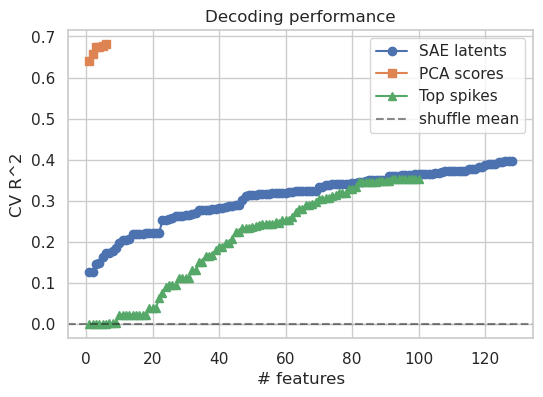

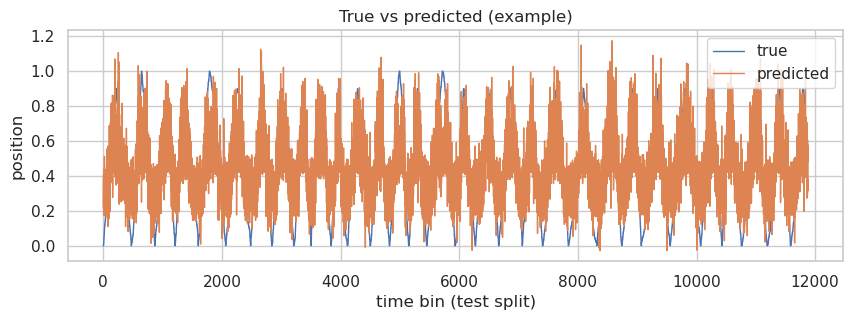

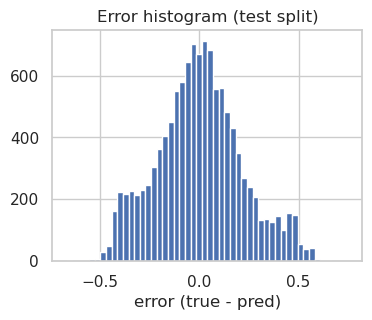

In [21]:
# ---------------------------
# Inputs you must have in scope
# ---------------------------
# Z: numpy array (T, L)  -> SAE latent timecourses (rows aligned with pos)
# pos: numpy array (T,)  -> continuous position along track
# spike_cts: numpy array (T, N) -> optional baseline
# pcs: numpy array (T, P) -> optional PCA scores (if you ran PCA), else compute below
# ---------------------------
from sklearn.preprocessing import StandardScaler

def cv_decode(X_features, y, n_splits=5, alpha=1.0):
    """Return mean and std of CV R^2 and RMSE for Ridge(alpha)."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    r2s = []
    rmses = []
    for tr, te in kf.split(X_features):
        model = Ridge(alpha=alpha)
        model.fit(X_features[tr], y[tr])
        yhat = model.predict(X_features[te])
        r2s.append(r2_score(y[te], yhat))
        rmses.append(np.sqrt(mean_squared_error(y[te], yhat)))
    return np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses)

def prepare_Z(Z):
    """
    Normalize shape to (T, D) or (T, n_inst, D) handling common saved formats.
    Returns Z_use (T, D) by default (taking instance 0 if multiple instances),
    and a dict describing alternatives.
    """
    info = {}
    if Z.ndim == 1:
        Z = Z.reshape(-1, 1)
    if Z.ndim == 2:
        # (T, D) already
        Z_use = Z
        info['mode'] = 'single'
    elif Z.ndim == 3:
        # (T, n_inst, D) or (T, D, n_inst) -- assume (T, n_inst, D)
        if Z.shape[1] <= 8 and Z.shape[2] > Z.shape[1]:  # heuristic
            # (T, n_inst, D): provide both single instance and concatenated
            inst0 = Z[:, 0, :]
            Z_concat = Z.reshape(Z.shape[0], -1)  # concat across instances
            Z_use = inst0
            info['mode'] = 'multi_instance'
            info['Z_concat'] = Z_concat
            info['n_inst'] = Z.shape[1]
        else:
            # fallback: squeeze middle
            Z_use = Z.squeeze(1)
            info['mode'] = 'squeezed'
    else:
        raise ValueError(f"Unexpected Z.ndim={Z.ndim}. Expected 2 or 3.")

    return Z_use.astype(np.float32), info

def decode_vs_features(Z_raw, pos, spike_cts=None, pcs=None, maxK=None, n_splits=5):
    """
    Compute CV decoding R^2 and RMSE as a function of number of features for:
      - SAE latents (Z)
      - PCA scores (pcs) if provided
      - raw spikes (spike_cts) if provided (typically use top-N by variance or all)
    Returns results dict and also prints summary.
    """
    T = pos.shape[0]
    results = {}

    # SAE latents
    Z_out = prepare_Z(Z_raw)
    print('shape of Z:', Z_raw.shape)
    print('shape of pos:', pos.shape)
    Z = Z_out[0]
    L = Z.shape[1]
    maxK_z = min(L, maxK) if maxK is not None else L
    r2_z = []; r2_z_std = []; rmse_z = []; rmse_z_std = []
    for K in range(1, maxK_z + 1):
        r_mean, r_std, rm, rmsd = cv_decode(Z[:, :K], pos, n_splits=n_splits)
        r2_z.append(r_mean); r2_z_std.append(r_std)
        rmse_z.append(rm); rmse_z_std.append(rmsd)
    results['sae'] = dict(Ks=list(range(1, maxK_z+1)), r2=np.array(r2_z), r2_std=np.array(r2_z_std),
                          rmse=np.array(rmse_z), rmse_std=np.array(rmse_z_std))

    # PCA baseline
    if pcs is None and spike_cts is not None:
        # quick PCA to get pcs if not provided
        from sklearn.decomposition import PCA
        pca = PCA(n_components=min(spike_cts.shape[1], 50))
        pcs = pca.fit_transform((np.sqrt(spike_cts + 3/8.0) - np.sqrt(spike_cts + 3/8.0).mean(axis=0)) / (np.sqrt(spike_cts + 3/8.0).std(axis=0)+1e-8))

    if pcs is not None:
        P = pcs.shape[1]
        maxK_p = min(P, maxK) if maxK is not None else P
        r2_p = []; r2_p_std = []; rmse_p = []; rmse_p_std = []
        for K in range(1, maxK_p + 1):
            r_mean, r_std, rm, rmsd = cv_decode(pcs[:, :K], pos, n_splits=n_splits)
            r2_p.append(r_mean); r2_p_std.append(r_std)
            rmse_p.append(rm); rmse_p_std.append(rmsd)
        results['pca'] = dict(Ks=list(range(1, maxK_p+1)), r2=np.array(r2_p), r2_std=np.array(r2_p_std),
                              rmse=np.array(rmse_p), rmse_std=np.array(rmse_p_std))

    # Raw spikes baseline (z-scored per neuron)
    if spike_cts is not None:
        # transfer spike_cts to cpu and then to numpy
        spike_cts = spike_cts.detach().cpu().to(t.float32).numpy()
        Xz = (np.sqrt(spike_cts + 3/8.0) - np.sqrt(spike_cts + 3/8.0).mean(axis=0)) / (np.sqrt(spike_cts + 3/8.0).std(axis=0)+1e-8)
        N = Xz.shape[1]
        maxK_s = min(N, maxK) if maxK is not None else min(50, N)
        # choose top features by variance for efficiency
        var_idx = np.argsort(Xz.var(axis=0))[::-1][:maxK_s]
        r2_s = []; r2_s_std = []; rmse_s = []; rmse_s_std = []
        for K in range(1, maxK_s + 1):
            cols = var_idx[:K]
            r_mean, r_std, rm, rmsd = cv_decode(Xz[:, cols], pos, n_splits=n_splits)
            r2_s.append(r_mean); r2_s_std.append(r_std)
            rmse_s.append(rm); rmse_s_std.append(rmsd)
        results['spikes'] = dict(Ks=list(range(1, maxK_s+1)), r2=np.array(r2_s), r2_std=np.array(r2_s_std),
                                rmse=np.array(rmse_s), rmse_std=np.array(rmse_s_std))

    return results

def shuffle_baseline(X_features, pos, n_shuffles=50, n_splits=5):
    """Shuffle pos and compute CV R^2 distribution to get chance level."""
    r2s = []
    rng = np.random.RandomState(0)
    for s in range(n_shuffles):
        pos_s = rng.permutation(pos)
        r_mean, r_std, _, _ = cv_decode(X_features, pos_s, n_splits=n_splits)
        r2s.append(r_mean)
    return np.mean(r2s), np.std(r2s)

# ---------------------------
# Example usage:
# ---------------------------
# Compute results (choose maxK to compare up to)
pos = pos_float32
Z_out = np.load("sae_latents_Z.npy")
pcs =  res['pcs']
results = decode_vs_features(Z_out, pos, spike_cts=spike_cts if 'spike_cts' in globals() else None,
                             pcs=pcs if 'pcs' in globals() else None, maxK=128, n_splits=5) #{64: 2, 128: 4, 256: 8}

Z = Z_out[:,0,:]
# Shuffle baseline for SAE top-K=1
sae_top1 = Z[:, :1]
shuffle_mean, shuffle_std = shuffle_baseline(sae_top1, pos, n_shuffles=100, n_splits=5)
print("Shuffle baseline R^2 (mean ± std):", shuffle_mean, shuffle_std)

# Print numeric summary
print("SAE top-1 CV R2:", results['sae']['r2'][0], "±", results['sae']['r2_std'][0])
if 'pca' in results: print("PCA top-1 CV R2:", results['pca']['r2'][0], "±", results['pca']['r2_std'][0])
if 'spikes' in results: print("Spike top-10 CV R2:", results['spikes']['r2'][-1], "±", results['spikes']['r2_std'][-1])

# ---------------------------
# Plots
# ---------------------------
# 1) R^2 vs #features
plt.figure(figsize=(6,4))
plt.plot(results['sae']['Ks'], results['sae']['r2'], label='SAE latents', marker='o')
if 'pca' in results: plt.plot(results['pca']['Ks'], results['pca']['r2'], label='PCA scores', marker='s')
if 'spikes' in results: plt.plot(results['spikes']['Ks'], results['spikes']['r2'], label='Top spikes', marker='^')
plt.axhline(shuffle_mean, color='k', linestyle='--', alpha=0.5, label='shuffle mean')
plt.fill_between(results['sae']['Ks'], shuffle_mean-shuffle_std, shuffle_mean+shuffle_std, color='k', alpha=0.1)
plt.xlabel("# features"); plt.ylabel("CV R^2"); plt.legend(); plt.title("Decoding performance")
plt.show()

# 2) Example true vs predicted trajectory (use all latents)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
train_idx, test_idx = next(kf.split(Z))
clf = Ridge(alpha=1.0).fit(Z[train_idx], pos[train_idx])
pos_hat = clf.predict(Z[test_idx])
plt.figure(figsize=(10,3))
plt.plot(pos[test_idx], label='true', lw=1)
plt.plot(pos_hat, label='predicted', lw=1)
plt.legend(); plt.xlabel("time bin (test split)"); plt.ylabel("position"); plt.title("True vs predicted (example)")
plt.show()

# 3) Error histogram
err = pos[test_idx] - pos_hat
plt.figure(figsize=(4,3))
plt.hist(err, bins=50)
plt.xlabel("error (true - pred)"); plt.title("Error histogram (test split)")
plt.show()


Zone (0.9, 1.0) -> 1939 samples out of 60000 total.
Zone decoding summary (R^2 mean ± std, RMSE mean ± std, n_samples):
K= 1 | SAE R2=0.008±0.004 RMSE=0.036±0.000 | PCA R2=0.463±0.021 RMSE=0.027±0.000 | Spikes R2=-0.003±0.002 RMSE=0.036±0.000 | n=1939
K= 2 | SAE R2=0.017±0.009 RMSE=0.036±0.000 | PCA R2=0.478±0.017 RMSE=0.026±0.000 | Spikes R2=-0.005±0.002 RMSE=0.036±0.000 | n=1939
K= 3 | SAE R2=0.022±0.007 RMSE=0.036±0.000 | PCA R2=0.495±0.021 RMSE=0.026±0.000 | Spikes R2=-0.005±0.003 RMSE=0.036±0.000 | n=1939
K= 5 | SAE R2=0.024±0.013 RMSE=0.036±0.000 | PCA R2=0.496±0.022 RMSE=0.026±0.000 | Spikes R2=-0.006±0.002 RMSE=0.036±0.000 | n=1939
K=10 | SAE R2=0.033±0.023 RMSE=0.036±0.000 | PCA R2=nan±nan RMSE=nan±nan | Spikes R2=-0.006±0.007 RMSE=0.036±0.000 | n=1939


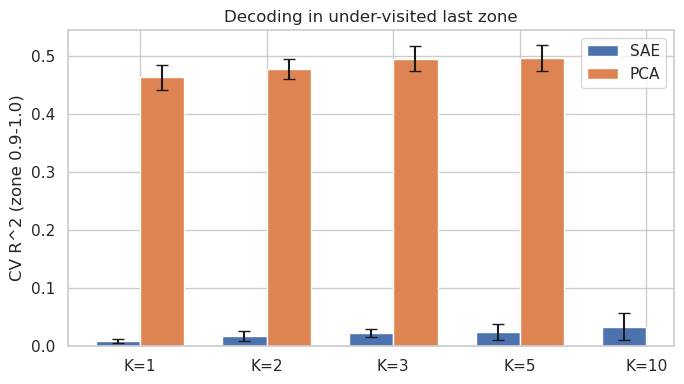

In [16]:
def decode_zone(Z_raw, pos, spike_cts=None, pcs=None, zone=(0.9, 1.0),
                K_list=(1,2,3,5,10), n_splits=5, alpha=1.0, min_samples_per_fold=5, verbose=True):
    """
    Evaluate decoding (CV R^2 & RMSE) restricted to timepoints where pos is within `zone`.
    Reuses cv_decode and prepare_Z.

    Args:
      Z_raw: SAE latents in any accepted format (passed to prepare_Z)
      pos: (T,) continuous positions
      spike_cts: optional (T,N) raw spikes (numpy or torch)
      pcs: optional (T,P) PCA scores; if None and spike_cts provided, pcs will be computed from spike_cts
      zone: (low, high) region in same units as pos (inclusive)
      K_list: iterable of K values to evaluate
      n_splits: desired number of CV folds (will be reduced if too few samples)
      alpha: Ridge regularization
      min_samples_per_fold: if number of samples < n_splits*min_samples_per_fold, reduce folds
      verbose: print progress

    Returns:
      dict with keys 'sae', 'pca', 'spikes' each mapping K -> (r2_mean, r2_std, rmse_mean, rmse_std, n_samples)
    """
    # select zone indices
    pos = np.asarray(pos).ravel()
    idx_zone = np.where((pos >= zone[0]) & (pos <= zone[1]))[0]
    n_zone = idx_zone.size
    if verbose:
        print(f"Zone {zone} -> {n_zone} samples out of {pos.shape[0]} total.")

    # require at least some samples
    if n_zone < 2:
        raise ValueError(f"Too few samples in zone {zone}: {n_zone}")

    # adapt n_splits conservatively to avoid tiny test folds
    # ensure at least min_samples_per_fold samples per fold when possible
    max_splits = max(2, min(n_splits, n_zone // max(1, min_samples_per_fold)))
    if max_splits < 2:
        # fallback: use 2 folds if possible
        max_splits = min(2, n_zone)
    if max_splits < 2:
        # can't do CV
        raise ValueError(f"Not enough samples ({n_zone}) for cross-validation with requested settings.")
    if verbose and max_splits != n_splits:
        print(f"Reducing n_splits from {n_splits} to {max_splits} because of limited samples in zone.")

    K_list = list(K_list)

    results_zone = {'sae': {}, 'pca': {}, 'spikes': {}}

    # -------------------------
    # SAE latents
    # -------------------------
    Z_use, info = prepare_Z(Z_raw)   # returns (T, D) and info
    Z_use = np.asarray(Z_use)
    # select zone rows
    Z_zone = Z_use[idx_zone]     # shape (n_zone, D)
    L = Z_zone.shape[1]

    for K in K_list:
        if K <= L:
            r_mean, r_std, rm, rmsd = cv_decode(Z_zone[:, :K], pos[idx_zone], n_splits=max_splits, alpha=alpha)
            results_zone['sae'][K] = (r_mean, r_std, rm, rmsd, n_zone)
        else:
            results_zone['sae'][K] = (np.nan, np.nan, np.nan, np.nan, n_zone)

    # -------------------------
    # PCA baseline (use provided pcs or compute from spike_cts)
    # -------------------------
    pcs_arr = pcs
    if pcs_arr is None and spike_cts is not None:
        # compute quick PCA on preprocessed spikes to get pcs aligned to full dataset
        # use same preprocessing as in decode_vs_features: sqrt+zscore
        Xtmp = np.asarray(spike_cts)
        Xtmp = np.sqrt(Xtmp + 3.0/8.0)
        Xtmp = (Xtmp - Xtmp.mean(axis=0)) / (Xtmp.std(axis=0) + 1e-8)
        pca = PCA(n_components=min(Xtmp.shape[1], 50))
        pcs_arr = pca.fit_transform(Xtmp)
        if verbose:
            print("Computed PCA scores from spike_cts for zone decoding.")
    if pcs_arr is not None:
        pcs_arr = np.asarray(pcs_arr)
        pcs_zone = pcs_arr[idx_zone]
        P = pcs_zone.shape[1]
        for K in K_list:
            if K <= P:
                r_mean, r_std, rm, rmsd = cv_decode(pcs_zone[:, :K], pos[idx_zone], n_splits=max_splits, alpha=alpha)
                results_zone['pca'][K] = (r_mean, r_std, rm, rmsd, n_zone)
            else:
                results_zone['pca'][K] = (np.nan, np.nan, np.nan, np.nan, n_zone)
    else:
        # mark NA if no PCA info
        for K in K_list:
            results_zone['pca'][K] = (np.nan, np.nan, np.nan, np.nan, n_zone)

    # -------------------------
    # Spikes baseline (top-variance neurons), if available
    # -------------------------
    if spike_cts is not None:
        # convert to numpy if torch tensor
        try:
            import torch
            if isinstance(spike_cts, torch.Tensor):
                Xsp = spike_cts.detach().cpu().to(t.float32).numpy()
            else:
                Xsp = np.asarray(spike_cts)
        except Exception:
            Xsp = np.asarray(spike_cts)
        # preprocess as above (sqrt + zscore)
        Xtmp = np.sqrt(Xsp + 3.0/8.0)
        Xtmp = (Xtmp - Xtmp.mean(axis=0)) / (Xtmp.std(axis=0) + 1e-8)
        X_zone = Xtmp[idx_zone]
        N = X_zone.shape[1]
        # choose top min(N, max(K_list)) by variance over the full dataset (consistent with decode_vs_features)
        var_idx = np.argsort(Xtmp.var(axis=0))[::-1]
        maxK_s = min(N, max(K_list))
        for K in K_list:
            if K <= maxK_s:
                cols = var_idx[:K]
                r_mean, r_std, rm, rmsd = cv_decode(X_zone[:, cols], pos[idx_zone], n_splits=max_splits, alpha=alpha)
                results_zone['spikes'][K] = (r_mean, r_std, rm, rmsd, n_zone)
            else:
                results_zone['spikes'][K] = (np.nan, np.nan, np.nan, np.nan, n_zone)
    else:
        for K in K_list:
            results_zone['spikes'][K] = (np.nan, np.nan, np.nan, np.nan, n_zone)

    if verbose:
        print("Zone decoding summary (R^2 mean ± std, RMSE mean ± std, n_samples):")
        for K in K_list:
            s = results_zone['sae'][K]
            p = results_zone['pca'][K]
            sp = results_zone['spikes'][K]
            print(f"K={K:2d} | SAE R2={s[0]:.3f}±{s[1]:.3f} RMSE={s[2]:.3f}±{s[3]:.3f} | "
                  f"PCA R2={p[0]:.3f}±{p[1]:.3f} RMSE={p[2]:.3f}±{p[3]:.3f} | "
                  f"Spikes R2={sp[0]:.3f}±{sp[1]:.3f} RMSE={sp[2]:.3f}±{sp[3]:.3f} | n={n_zone}")
    return results_zone


# ---------------------------
# Example usage (using your variables from earlier)
# ---------------------------
# Z_out = np.load("sae_latents_Z.npy", allow_pickle=True)  # however you stored it
# pos = pos_float32            # your discrete or continuous pos array
# pcs = res['pcs']             # PCA scores computed earlier (optional)
# spike_cts = spike_cts       # your (T,N) spike matrix (optional)

# If Z_out is the object you loaded earlier that might be e.g. (T, inst, D) or a tuple:
# Use prepare_Z to normalize; decode_zone will call prepare_Z internally.

# Run zone decoding for last 10 cm:
zone_results = decode_zone(Z_out, pos, spike_cts=spike_cts if 'spike_cts' in globals() else None,
                           pcs=pcs if 'pcs' in globals() else None,
                           zone=(0.9, 1.0),
                           K_list=(1,2,3,5,10),
                           n_splits=5,
                           alpha=1.0,
                           verbose=True)

# ---------------------------
# Optional quick plotting helper: compare SAE vs PCA R^2 for each K in the zone
# ---------------------------
def plot_zone_comparison(zone_results, K_list=(1,2,3,5,10)):
    Ks = list(K_list)
    sae_means = [zone_results['sae'][K][0] for K in Ks]
    sae_stds  = [zone_results['sae'][K][1] for K in Ks]
    pca_means = [zone_results['pca'][K][0] for K in Ks]
    pca_stds  = [zone_results['pca'][K][1] for K in Ks]

    x = np.arange(len(Ks))
    width = 0.35
    fig, ax = plt.subplots(figsize=(7,4))
    ax.bar(x - width/2, sae_means, width, yerr=sae_stds, label='SAE', capsize=4)
    ax.bar(x + width/2, pca_means, width, yerr=pca_stds, label='PCA', capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels([f"K={k}" for k in Ks])
    ax.set_ylabel("CV R^2 (zone 0.9-1.0)")
    ax.set_title("Decoding in under-visited last zone")
    ax.legend()
    plt.tight_layout()
    plt.show()

# call plot (optional)
plot_zone_comparison(zone_results, K_list=(1,2,3,5,10))



In [ ]:
# add at top of your notebook
from sklearn.decomposition import NMF

# -------------------------
# Replace PCA baseline in decode_vs_features with sparse-NMF baseline
# -------------------------


def cv_decode(X_features, y, n_splits=5, alpha=1.0, random_state=0):
    """
    Safe CV decoding wrapper that:
      - coerces inputs to numpy
      - checks shapes match
      - reduces n_splits if necessary
      - returns mean/std R^2 and RMSE across folds
    """
    # Ensure numpy arrays and correct shapes
    X_features = np.asarray(X_features)
    y = np.asarray(y).ravel()
    n_samples = X_features.shape[0]
    """
    if X_features.ndim == 1:
        X_features = X_features.reshape(-1, 1)
    if X_features.ndim != 2:
        raise ValueError(f"X_features must be 2D (n_samples, n_feats). Got shape {X_features.shape}")
   
    if n_samples != y.shape[0]:
        raise ValueError(f"Length mismatch: X_features has {n_samples} rows but y has length {y.shape[0]}")
     """
    # Ensure n_splits is sensible relative to n_samples
    # Need at least 2 folds, and each fold should have at least one sample.
    if n_splits < 2:
        n_splits = 2
    if n_splits > n_samples:
        # reduce to a maximum of n_samples folds (degenerate) but prefer at most n_samples//2
        new_splits = max(2, min(n_samples, n_splits))
        # in practice choose floor(n_samples/ min_test_size) but simplest:
        n_splits = new_splits
    

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=0)
    r2s = []
    rmses = []
    for tr, te in kf.split(X_features):
        model = Ridge(alpha=alpha)
        model.fit(X_features[tr], y[tr])
        yhat = model.predict(X_features[te])
        r2s.append(r2_score(y[te], yhat))
        rmses.append(np.sqrt(mean_squared_error(y[te], yhat)))
    return np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses)

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)


def decode_vs_features(Z_raw, pos, spike_cts=None, nmf_w=None, maxK=None, n_splits=5):
    """
    Compute CV decoding R^2 and RMSE as a function of number of features for:
      - SAE latents (Z)
      - sparse NMF activations (nmf_w) computed from spike_cts (if provided)
      - raw spikes (spike_cts) if provided
    Returns results dict and prints summary.
    """
    T = pos.shape[0]
    results = {}

    # SAE latents (unchanged)
    print('shape of Z_raw:', Z_raw.shape)
    Z_out = prepare_Z(Z_raw)
    Z = Z_out[0]
    L = Z.shape[1]
    maxK_z = min(L, maxK) if maxK is not None else L
    r2_z = []; r2_z_std = []; rmse_z = []; rmse_z_std = []
    for K in range(1, maxK_z + 1):
        r_mean, r_std, rm, rmsd = cv_decode(Z[:, :K], pos, n_splits=n_splits)
        r2_z.append(r_mean); r2_z_std.append(r_std)
        rmse_z.append(rm); rmse_z_std.append(rmsd)
    results['sae'] = dict(Ks=list(range(1, maxK_z+1)), r2=np.array(r2_z), r2_std=np.array(r2_z_std),
                          rmse=np.array(rmse_z), rmse_std=np.array(rmse_z_std))

    # -------------------------
    # sparse NMF baseline: if nmf_w not provided, compute from spike_cts
    # -------------------------
    if nmf_w is None and spike_cts is not None:
        # convert spike_cts to numpy and safe dtype (handle torch.bfloat16)
        try:
            import torch
            if isinstance(spike_cts, torch.Tensor):
                X_sp = spike_cts.detach().cpu().to(torch.float32).numpy()
            else:
                X_sp = np.asarray(spike_cts)
        except Exception:
            X_sp = np.asarray(spike_cts)

        # Preprocess same as before: sqrt + per-neuron zscore (NMF expects nonnegative input if possible)
        # Keep nonnegativity by using sqrt only (z-scoring would create negatives). NMF requires non-negative input.
        # So we'll use sqrt transform (Anscombe) WITHOUT z-scoring for NMF; preserve sign/scale for NMF.
        X_for_nmf = np.sqrt(X_sp + 3.0/8.0)
        # Option: you could standardize after shifting minimum to zero, but plain sqrt is standard for count data.

        n_components = min(X_for_nmf.shape[1], 50) if maxK is None else min(maxK, X_for_nmf.shape[1], 50)
        # NMF hyperparams (example defaults). Tune alpha and l1_ratio to encourage sparsity.
        nmf = NMF(n_components=n_components, init='nndsvda', solver='cd',
                  beta_loss='frobenius', max_iter=500, random_state=0, 
                  alpha_W = 0.01, alpha_H = 0.0, l1_ratio=0.8)  # alpha & l1_ratio control sparsity/regularization
        # Fit NMF on the whole dataset to get time × components activations W
        nmf_w = nmf.fit_transform(X_for_nmf)  # shape (T, n_components)
        # note: nmf.components_ is H (n_components, n_features)

    if nmf_w is not None:
        nmf_w = np.asarray(nmf_w)
        P = nmf_w.shape[1]
        maxK_p = min(P, maxK) if maxK is not None else P
        r2_p = []; r2_p_std = []; rmse_p = []; rmse_p_std = []
        for K in range(1, maxK_p + 1):
            r_mean, r_std, rm, rmsd = cv_decode(nmf_w[:, :K], pos, n_splits=n_splits)
            r2_p.append(r_mean); r2_p_std.append(r_std)
            rmse_p.append(rm); rmse_p_std.append(rmsd)
        results['nmf'] = dict(Ks=list(range(1, maxK_p+1)), r2=np.array(r2_p), r2_std=np.array(r2_p_std),
                              rmse=np.array(rmse_p), rmse_std=np.array(rmse_p_std))
    else:
        results['nmf'] = None

    # Raw spikes baseline (same as before, but ensure dtype conversion to float32)
    if spike_cts is not None:
        try:
            import torch
            if isinstance(spike_cts, torch.Tensor):
                spike_cts_np = spike_cts.detach().cpu().to(torch.float32).numpy()
            else:
                spike_cts_np = np.asarray(spike_cts)
        except Exception:
            spike_cts_np = np.asarray(spike_cts)

        Xz = (np.sqrt(spike_cts_np + 3/8.0) - np.sqrt(spike_cts_np + 3/8.0).mean(axis=0)) / (np.sqrt(spike_cts_np + 3/8.0).std(axis=0)+1e-8)
        N = Xz.shape[1]
        maxK_s = min(N, maxK) if maxK is not None else min(50, N)
        # choose top features by variance for efficiency
        var_idx = np.argsort(Xz.var(axis=0))[::-1][:maxK_s]
        r2_s = []; r2_s_std = []; rmse_s = []; rmse_s_std = []
        for K in range(1, maxK_s + 1):
            cols = var_idx[:K]
            r_mean, r_std, rm, rmsd = cv_decode(Xz[:, cols], pos, n_splits=n_splits)
            r2_s.append(r_mean); r2_s_std.append(r_std)
            rmse_s.append(rm); rmse_s_std.append(rmsd)
        results['spikes'] = dict(Ks=list(range(1, maxK_s+1)), r2=np.array(r2_s), r2_std=np.array(r2_s_std),
                                rmse=np.array(rmse_s), rmse_std=np.array(rmse_s_std))

    return results


# -------------------------
# Also adapt decode_zone() to use NMF instead of PCA (if you use that function)
# -------------------------
def decode_zone_with_nmf(Z_raw, pos, spike_cts=None, nmf_w=None, zone=(0.9, 1.0),
                         K_list=(1,2,3,5,10), n_splits=5, alpha=1.0, min_samples_per_fold=5, verbose=True):
    """
    Wrapper like decode_zone but refers to nmf features instead of pca.
    """
    # use previous decode_zone but replace 'pca' paths with 'nmf'
    # For brevity we reuse decode_zone implementation by temporarily passing pcs=None and enabling computing nmf inside decode_vs_features
    # Simpler: call decode_zone (existing) but modify it to look for nmf. To keep it explicit, here we compute nmf activations then call cv_decode on them restricted to zone.

    pos = np.asarray(pos).ravel()
    idx_zone = np.where((pos >= zone[0]) & (pos <= zone[1]))[0]
    n_zone = idx_zone.size
    if verbose:
        print(f"Zone {zone} -> {n_zone} samples out of {pos.shape[0]} total.")
    if n_zone < 2:
        raise ValueError(f"Too few samples in zone {zone}: {n_zone}")

    # choose folds
    max_splits = max(2, min(n_splits, n_zone // max(1, min_samples_per_fold)))
    if max_splits < 2:
        max_splits = min(2, n_zone)
    if max_splits < 2:
        raise ValueError("Not enough samples for CV in zone.")

    results_zone = {'sae': {}, 'nmf': {}, 'spikes': {}}

    # SAE zone decoding
    Z_use, info = prepare_Z(Z_raw)
    Z_zone = Z_use[idx_zone]
    L = Z_zone.shape[1]
    for K in K_list:
        if K <= L:
            r_mean, r_std, rm, rmsd = cv_decode(Z_zone[:, :K], pos[idx_zone], n_splits=max_splits, alpha=alpha)
            results_zone['sae'][K] = (r_mean, r_std, rm, rmsd, n_zone)
        else:
            results_zone['sae'][K] = (np.nan,)*5

    # NMF zone decoding (compute nmf_w if not provided)
    if nmf_w is None and spike_cts is not None:
        try:
            import torch
            if isinstance(spike_cts, torch.Tensor):
                X_sp = spike_cts.detach().cpu().to(torch.float32).numpy()
            else:
                X_sp = np.asarray(spike_cts)
        except Exception:
            X_sp = np.asarray(spike_cts)
        X_for_nmf = np.sqrt(X_sp + 3.0/8.0)
        n_components = min(X_for_nmf.shape[1], 50)
        nmf = NMF(n_components=n_components, init='nndsvda', solver='cd',
                  beta_loss='frobenius', max_iter=500, random_state=0,
                  alpha_W = 0.01, alpha_H = 0.0, l1_ratio=0.8)
        nmf_w = nmf.fit_transform(X_for_nmf)

    if nmf_w is not None:
        nmf_zone = np.asarray(nmf_w)[idx_zone]
        P = nmf_zone.shape[1]
        for K in K_list:
            if K <= P:
                r_mean, r_std, rm, rmsd = cv_decode(nmf_zone[:, :K], pos[idx_zone], n_splits=max_splits, alpha=alpha)
                results_zone['nmf'][K] = (r_mean, r_std, rm, rmsd, n_zone)
            else:
                results_zone['nmf'][K] = (np.nan,)*5
    else:
        for K in K_list:
            results_zone['nmf'][K] = (np.nan,)*5

    # spikes baseline zone decoding (same as before)
    if spike_cts is not None:
        try:
            import torch
            if isinstance(spike_cts, torch.Tensor):
                Xsp = spike_cts.detach().cpu().to(torch.float32).numpy()
            else:
                Xsp = np.asarray(spike_cts)
        except Exception:
            Xsp = np.asarray(spike_cts)
        Xtmp = np.sqrt(Xsp + 3.0/8.0)
        X_zone = (Xtmp - Xtmp.mean(axis=0)) / (Xtmp.std(axis=0) + 1e-8)
        var_idx = np.argsort(Xtmp.var(axis=0))[::-1]
        N = X_zone.shape[1]
        for K in K_list:
            if K <= N:
                cols = var_idx[:K]
                r_mean, r_std, rm, rmsd = cv_decode(X_zone[:, cols], pos[idx_zone], n_splits=max_splits, alpha=alpha)
                results_zone['spikes'][K] = (r_mean, r_std, rm, rmsd, n_zone)
            else:
                results_zone['spikes'][K] = (np.nan,)*5

    return results_zone


Z_out = np.load("sae_latents_Z.npy")
print('shape of Z_out:', Z_out.shape)
results = decode_vs_features(Z_out, pos, spike_cts=spike_cts, nmf_w=None, maxK=20, n_splits=5)


zone_results = decode_zone_with_nmf(Z_out, pos, spike_cts=spike_cts, zone=(0.9,1.0), K_list=(1,2,3,5,10))


# ---------------------------
# Plots
# ---------------------------
# 1) R^2 vs #features
plt.figure(figsize=(6,4))
plt.plot(results['sae']['Ks'], results['sae']['r2'], label='SAE latents', marker='o')
if 'nmf' in results: plt.plot(results['nmf']['Ks'], results['nmf']['r2'], label='nmf latents', marker='s')
if 'spikes' in results: plt.plot(results['spikes']['Ks'], results['spikes']['r2'], label='Top spikes', marker='^')
plt.axhline(shuffle_mean, color='k', linestyle='--', alpha=0.5, label='shuffle mean')
plt.fill_between(results['sae']['Ks'], shuffle_mean-shuffle_std, shuffle_mean+shuffle_std, color='k', alpha=0.1)
plt.xlabel("# features"); plt.ylabel("CV R^2"); plt.legend(); plt.title("Decoding performance")
plt.show()

# 2) Example true vs predicted trajectory (use all latents)
kf = KFold(n_splits=5, shuffle=True, random_state=0)
train_idx, test_idx = next(kf.split(Z))
clf = Ridge(alpha=1.0).fit(Z[train_idx], pos[train_idx])
pos_hat = clf.predict(Z[test_idx])
plt.figure(figsize=(10,3))
plt.plot(pos[test_idx], label='true', lw=1)
plt.plot(pos_hat, label='predicted', lw=1)
plt.legend(); plt.xlabel("time bin (test split)"); plt.ylabel("position"); plt.title("True vs predicted (example)")
plt.show()

# 3) Error histogram
err = pos[test_idx] - pos_hat
plt.figure(figsize=(4,3))
plt.hist(err, bins=50)
plt.xlabel("error (true - pred)"); plt.title("Error histogram (test split)")
plt.show()

plot_zone_comparison(zone_results, K_list=(1,2,3,5,10))

shape of Z_out: (59392, 2, 128)
shape of Z_raw: (59392, 2, 128)


NameError: name 'n_samples' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------
# Utility / preprocessing
# ---------------------------
def smooth_counts(X, sigma=2):
    """Gaussian smoothing along time axis (axis=0). X shape (T, N)."""
    if sigma is None or sigma <= 0:
        return X.copy()
    from scipy.ndimage import gaussian_filter1d
    return gaussian_filter1d(X, sigma=sigma, axis=0, mode='reflect')

def anscombe_transform(X):
    """Variance-stabilizing sqrt-ish transform for Poisson counts."""
    return np.sqrt(X + 3.0/8.0)

def make_history_features(X, k):
    """
    Create concatenated temporal window features.
    X: (T, N)
    k: half-window size -> window length W = 2*k+1
    returns Xw: (T, N * W) where each row centered at t
    uses reflect padding
    """
    T, N = X.shape
    W = 2*k + 1
    pad = np.pad(X, ((k, k), (0, 0)), mode='reflect')
    Xw = np.empty((T, N * W), dtype=X.dtype)
    for t in range(T):
        block = pad[t:t+W]           # shape (W, N)
        Xw[t] = block.reshape(-1)    # flattened W*N
    return Xw

# ---------------------------
# CV decoding functions
# ---------------------------
def cv_ridge_decode(X, y, n_splits=5, alpha=1.0, random_state=0):
    """
    Cross-validated Ridge. Properly scales features on train only.
    Returns: mean_R2, std_R2, mean_RMSE, std_RMSE, preds (aligned with y)
    """
    X = np.asarray(X)
    y = np.asarray(y).ravel()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    preds = np.zeros_like(y, dtype=np.float32)
    r2s = []
    rmses = []
    for tr, te in kf.split(X):
        scaler = StandardScaler().fit(X[tr])    # fit scaler on train only
        Xtr = scaler.transform(X[tr])
        Xte = scaler.transform(X[te])
        model = Ridge(alpha=alpha)
        model.fit(Xtr, y[tr])
        yhat = model.predict(Xte)
        preds[te] = yhat
        r2s.append(r2_score(y[te], yhat))
        rmses.append(np.sqrt(mean_squared_error(y[te], yhat)))
    return np.mean(r2s), np.std(r2s), np.mean(rmses), np.std(rmses), preds

def circular_shift_shuffle_baseline(X, y, n_shufs=100, n_splits=5, alpha=1.0):
    """Circularly shift y to get conservative null distribution for CV R^2."""
    rng = np.random.RandomState(0)
    r2s = []
    for _ in range(n_shufs):
        shift = rng.randint(1, len(y))
        y_sh = np.roll(y, shift)
        r_mean, _, _, _, _ = cv_ridge_decode(X, y_sh, n_splits=n_splits, alpha=alpha)
        r2s.append(r_mean)
    return np.mean(r2s), np.std(r2s)

# ---------------------------
# Main demo function
# ---------------------------
def decode_from_spikes(spike_cts,
                       pos,
                       window_k=0,           # half-window; 0 = no temporal history
                       smooth_sigma=2,       # smoothing sigma in bins (None or 0 disables)
                       transform='anscombe', # 'anscombe', 'log1p', or None
                       use_zscore=True,      # per-neuron z-scoring applied AFTER transform
                       n_splits=5,
                       alpha=1.0,
                       n_shuf=100,
                       plot=True):
    """
    Decode continuous position from spike counts using linear ridge regression.
    spike_cts: (T, N) numpy array of counts
    pos: (T,) continuous positions (same time alignment)
    Returns results dict.
    """
    # ensure arrays
    X = np.asarray(spike_cts)
    y = np.asarray(pos).ravel()
    assert X.shape[0] == y.shape[0], "Time dimension mismatch"

    # smoothing
    if smooth_sigma is not None and smooth_sigma > 0:
        Xp = smooth_counts(X, sigma=smooth_sigma)
    else:
        Xp = X.copy()

    # transform
    if transform == 'anscombe':
        Xp = anscombe_transform(Xp)
    elif transform == 'log1p':
        Xp = np.log1p(Xp)
    elif transform is None:
        pass
    else:
        raise ValueError("transform must be 'anscombe', 'log1p', or None")

    # z-score per neuron if requested (useful for linear decoders)
    if use_zscore:
        mu = Xp.mean(axis=0, keepdims=True)
        sd = Xp.std(axis=0, keepdims=True)
        sd[sd < 1e-8] = 1.0
        Xp = (Xp - mu) / sd

    # add temporal history by concatenation if requested
    if window_k is not None and window_k > 0:
        Xfeat = make_history_features(Xp, window_k)  # (T, N*(2k+1))
    else:
        Xfeat = Xp  # (T, N)

    # run CV decode
    r2_mean, r2_std, rm_mean, rm_std, preds = cv_ridge_decode(Xfeat, y, n_splits=n_splits, alpha=alpha)

    # shuffle baseline (circular shift)
    sh_mean, sh_std = circular_shift_shuffle_baseline(Xfeat, y, n_shufs=n_shuf, n_splits=n_splits, alpha=alpha)

    results = dict(
        Xfeat = Xfeat,
        y = y,
        preds = preds,
        cv_r2 = r2_mean,
        cv_r2_std = r2_std,
        cv_rmse = rm_mean,
        cv_rmse_std = rm_std,
        shuffle_mean = sh_mean,
        shuffle_std = sh_std
    )

    if plot:
        # 1) Print summary
        print(f"Ridge CV R^2 = {r2_mean:.4f} ± {r2_std:.4f}")
        print(f"Shuffle (circular) baseline R^2 = {sh_mean:.4f} ± {sh_std:.4f}")
        print(f"RMSE = {rm_mean:.4f} ± {rm_std:.4f}")

        # 2) plot true vs predicted on example range
        T = len(y)
        # pick a test segment from the CV preds: find indices where preds differ from 0 (preds filled for all points)
        start = min(100, T//10)
        end = min(start + 500, T)
        plt.figure(figsize=(10,3))
        plt.plot(y[start:end], label='true', lw=1)
        plt.plot(preds[start:end], label='pred', lw=1)
        plt.legend(); plt.xlabel('time bin'); plt.ylabel('position'); plt.title('True vs predicted (example slice)')
        plt.show()

        # 3) error histogram
        resid = y - preds
        plt.figure(figsize=(4,3))
        plt.hist(resid, bins=50)
        plt.xlabel('pos_true - pos_pred'); plt.title('Residuals histogram'); plt.show()

    return results

# ---------------------------
# Example usage
# ---------------------------
# Load data (replace with your paths/variables)
spike_cts = np.load("./" + folder + "/spike_matrix.npy") # shape (N, T)
pos = np.load("./" + folder + "/positions.npy")          # shape (T,)

print("Decoding from spikes shape:", spike_cts.shape, "and pos shape:", pos.shape)
result = decode_from_spikes(spike_cts.T, pos,
                             window_k=5,         # use 11-bin window of history
                             smooth_sigma=2,
                             transform='anscombe',
                             use_zscore=True,
                             n_splits=5,
                             alpha=1.0,
                             n_shuf=100,
                             plot=True)

print("Done. CV R^2:", result['cv_r2'])


In [ ]:
print("Decoding from spikes shape:", spike_cts.shape, "and pos shape:", pos.shape)

In [ ]:

## Make boxplot of decoding error

def ensure_numpy(arr):
    try:
        import torch
        if isinstance(arr, torch.Tensor):
            arr = arr.detach().cpu().numpy()
    except Exception:
        pass
    arr = np.asarray(arr)
    # convert float16/bfloat to float32 if present
    if arr.dtype == np.float16 or str(arr.dtype).lower().startswith("bfloat"):
        arr = arr.astype(np.float32)
    return arr

def cv_ridge_rmse_per_fold(X, y, n_splits=5, alpha=1.0, random_state=0):
    """Return list of RMSE values (one per CV fold)."""
    X = ensure_numpy(X)
    y = np.asarray(y).ravel()
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rmses = []
    for tr, te in kf.split(X):
        scaler = StandardScaler().fit(X[tr])
        Xtr = scaler.transform(X[tr])
        Xte = scaler.transform(X[te])
        model = Ridge(alpha=alpha)
        model.fit(Xtr, y[tr])
        yhat = model.predict(Xte)
        rmses.append(np.sqrt(mean_squared_error(y[te], yhat)))
    return rmses

# K list: use results['sae']['Ks'] if available else default
if isinstance(results, dict) and 'sae' in results and 'Ks' in results['sae']:
    K_LIST = list(results['sae']['Ks'])
else:
    # fallback ks
    K_LIST = [1,2,3,5,10]

n_splits = 5
alpha = 1.0

# ---------- compute per-fold RMSEs for each K ----------
sae_rmses_per_K = {}
pca_rmses_per_K = {}

# get pcs: prefer pcs variable or results['pca']['pcs'] or compute from spike_cts if available
pcs_arr = None
if 'pcs' in globals():
    pcs_arr = pcs
elif isinstance(results, dict) and 'pca' in results and isinstance(results['pca'], dict) and 'pcs' in results['pca']:
    pcs_arr = results['pca']['pcs']
elif 'spike_cts' in globals():
    # quick PCA fallback if required (limited components)
    from sklearn.decomposition import PCA
    Xtmp = ensure_numpy(spike_cts)
    Xtmp = np.sqrt(Xtmp + 3./8.)
    Xtmp = (Xtmp - Xtmp.mean(axis=0)) / (Xtmp.std(axis=0) + 1e-8)
    pca = PCA(n_components=min(50, Xtmp.shape[1]))
    pcs_arr = pca.fit_transform(Xtmp)
else:
    pcs_arr = None
    print("No PCA scores available; PCA baseline will be skipped.")

for K in K_LIST:
    # SAE latents
    if K <= Z.shape[1]:
        sae_rmses_per_K[K] = cv_ridge_rmse_per_fold(Z[:, :K], pos, n_splits=n_splits, alpha=alpha)
    else:
        sae_rmses_per_K[K] = [np.nan]*n_splits

    # PCA baseline
    if pcs_arr is not None and K <= pcs_arr.shape[1]:
        pca_rmses_per_K[K] = cv_ridge_rmse_per_fold(pcs_arr[:, :K], pos, n_splits=n_splits, alpha=alpha)
    else:
        pca_rmses_per_K[K] = [np.nan]*n_splits

# ---------- make side-by-side boxplot ----------
fig, ax = plt.subplots(figsize=(10,5))

boxes = []
positions = []
labels = []
step = 3  # spacing between groups
width = 0.9

for i, K in enumerate(K_LIST):
    pos_center = i * step
    pos_pca = pos_center - 0.6
    pos_sae = pos_center + 0.6

    boxes.append((pca_rmses_per_K[K], pos_pca, 'PCA'))
    boxes.append((sae_rmses_per_K[K], pos_sae, 'SAE'))
    positions.extend([pos_pca, pos_sae])
    labels.extend([f"PCA K={K}", f"SAE K={K}"])

# extract data for plotting in the same order
data = [b[0] for b in boxes]
plot_pos = [b[1] for b in boxes]
bp = ax.boxplot(data, positions=plot_pos, widths=1.0, patch_artist=True, notch=True)

# color styling
for patch, meta in zip(bp['boxes'], labels):
    if meta.startswith("PCA"):
        patch.set_facecolor("#6baed6")
    else:
        patch.set_facecolor("#fd8d3c")

# x ticks
mid_positions = []
xticklabels = []
for i, K in enumerate(K_LIST):
    mid_positions.append(i * step)
    xticklabels.append(f"K={K}")
ax.set_xticks(mid_positions)
ax.set_xticklabels(xticklabels)
ax.set_ylabel("RMSE (position units)")
ax.set_title("Decoding RMSE per CV fold: PCA vs SAE latents")
ax.grid(axis='y', alpha=0.3)

# legend
import matplotlib.patches as mpatches
p1 = mpatches.Patch(color="#6baed6", label="PCA")
p2 = mpatches.Patch(color="#fd8d3c", label="SAE")
ax.legend(handles=[p1,p2], loc='upper right')

plt.tight_layout()
plt.show()

# ---------- print numeric summary ----------
print("Summary RMSE (mean ± std over folds) per K")
for K in K_LIST:
    s = np.array(sae_rmses_per_K[K], dtype=np.float32)
    p = np.array(pca_rmses_per_K.get(K, [np.nan]*len(s)), dtype=np.float32)
    print(f"K={K:2d} | SAE RMSE = {np.nanmean(s):.4f} ± {np.nanstd(s):.4f}  |  PCA RMSE = {np.nanmean(p):.4f} ± {np.nanstd(p):.4f}")
